In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

In [3]:
# Load Breast Cancer Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Original Class Distribution:")
print(Counter(y))

Original Class Distribution:
Counter({1: 357, 0: 212})


In [4]:
# Keep all majority class samples
majority = X[y == 1]
majority_y = y[y == 1]

# Keep only 30 minority class samples
minority = X[y == 0][:30]
minority_y = y[y == 0][:30]

X = pd.concat([majority, minority])
y = pd.concat([majority_y, minority_y])

print("Imbalanced Class Distribution:")
print(Counter(y))

Imbalanced Class Distribution:
Counter({1: 357, 0: 30})


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

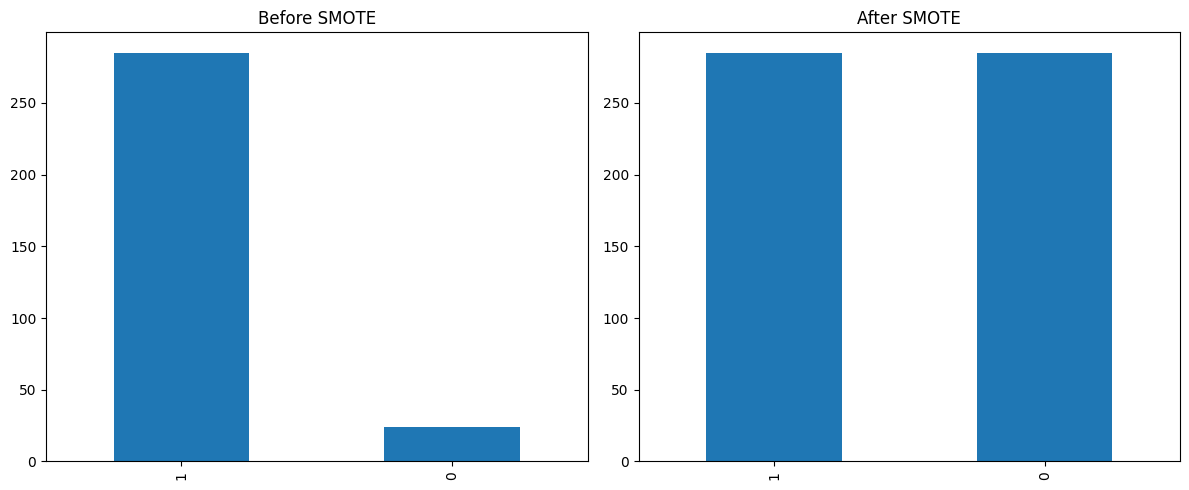

In [7]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Before SMOTE")

plt.subplot(1, 2, 2)
pd.Series(y_resampled).value_counts().plot(kind='bar')
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

In [8]:
model = RandomForestClassifier(random_state=42)

model.fit(X_resampled, y_resampled)

predictions = model.predict(X_test)

In [9]:
print("Classification Report")
print(classification_report(y_test, predictions))

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.97      0.99        72

    accuracy                           0.97        78
   macro avg       0.88      0.99      0.92        78
weighted avg       0.98      0.97      0.98        78

